# Ballot support and finance correlations

This notebook creates simple candidate-level electoral support measures from the
2024 VoteKit preference profiles and compares them with the fundraising variables
created in `02_fundraising_profiles.ipynb`.

Questions:

- Do candidates who raise more money receive more ballot mentions?
- Do candidates with more contribution records receive more ballot mentions?
- Is fundraising associated with first-place votes?
- Are fundraising-profile shares associated with support?
- Do the relationships look different across districts?


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from votekit.pref_profile import PreferenceProfile
from votekit.utils import mentions, first_place_votes
from votekit.elections import STV

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

YEAR = 2024
DISTRICTS = [1, 2, 3, 4]

cwd = Path.cwd()

if (cwd / "pyproject.toml").exists():
    ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find repository root. Expected pyproject.toml "
        "in the current directory or its parent."
    )

PROFILE_DIR = (
    ROOT / "data" / "raw" / "report2025" / "2024"
    / "cleaned_votekit_profiles"
)

CROSSWALK_PATH = (
    ROOT / "data" / "processed" / "master"
    / f"candidate_source_crosswalk_{YEAR}.csv"
)

FUNDRAISING_WIDE_PATH = (
    ROOT / "data" / "processed" / "fundraising" / str(YEAR)
    / "candidate_fundraising_profiles_wide.csv"
)

OUTPUT_DIR = (
    ROOT / "data" / "processed" / "ballot_support" / str(YEAR)
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("VoteKit profiles exist:", PROFILE_DIR.exists())
print("Crosswalk exists:", CROSSWALK_PATH.exists())
print("Fundraising profiles exist:", FUNDRAISING_WIDE_PATH.exists())

ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis
VoteKit profiles exist: True
Crosswalk exists: True
Fundraising profiles exist: True


## 1. Build ballot-support measures from VoteKit

For each candidate we calculate:

- `mentions`: weighted ballots mentioning the candidate anywhere;
- `mention_share`: mentions / total ballot weight;
- `first_place_votes`: weighted first-place votes;
- `first_place_share`: first-place votes / total ballot weight;
- `is_viable`: whether mentions are at least the district STV threshold.

In [2]:
support_rows = []

for district in DISTRICTS:
    profile_path = (
        PROFILE_DIR
        / f"Portland_D{district}_cleaned_votekit_pref_profile.pkl"
    )

    if not profile_path.exists():
        raise FileNotFoundError(f"Missing VoteKit profile: {profile_path}")

    profile = PreferenceProfile.from_pickle(profile_path)

    mention_dict = mentions(profile)
    fpv_dict = first_place_votes(profile)

    election = STV(profile, m=3)
    threshold = float(election.threshold)
    total_ballot_weight = float(profile.total_ballot_wt)

    for candidate in profile.candidates:
        candidate_mentions = float(mention_dict.get(candidate, 0))
        candidate_fpv = float(fpv_dict.get(candidate, 0))

        support_rows.append(
            {
                "year": YEAR,
                "district": district,
                "source_candidate_name": candidate,
                "mentions": candidate_mentions,
                "mention_share": (
                    candidate_mentions / total_ballot_weight
                    if total_ballot_weight else np.nan
                ),
                "first_place_votes": candidate_fpv,
                "first_place_share": (
                    candidate_fpv / total_ballot_weight
                    if total_ballot_weight else np.nan
                ),
                "total_ballot_weight": total_ballot_weight,
                "stv_threshold": threshold,
                "is_viable": candidate_mentions >= threshold,
            }
        )

support_raw = pd.DataFrame(support_rows)

print("VoteKit candidate rows:", len(support_raw))
display(support_raw.groupby("district").size().rename("candidate_rows"))

/Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/.venv/lib/python3.11/site-packages/votekit/pref_profile/pref_profile.py:1109: UserWarning: Profile does not contain rankings but max_ranking_length=6. Setting max_ranking_length to 0.
  warnings.warn(


Initial tiebreak was unsuccessful, performing random tiebreak
VoteKit candidate rows: 102


/Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/.venv/lib/python3.11/site-packages/votekit/pref_profile/pref_profile.py:1109: UserWarning: Profile does not contain rankings but max_ranking_length=6. Setting max_ranking_length to 0.
  warnings.warn(


district
1    17
2    23
3    31
4    31
Name: candidate_rows, dtype: int64

## 2. Link VoteKit names to the official candidate universe

We use the existing `report2025` source crosswalk rather than doing new
ad-hoc name matching. Non-candidate labels such as `Uncertified Write In`
remain outside the official-candidate analysis.

In [3]:
crosswalk = pd.read_csv(CROSSWALK_PATH, low_memory=False)

report_crosswalk = crosswalk.loc[
    crosswalk["source"].eq("report2025")
].copy()

matched_report = (
    report_crosswalk.loc[
        report_crosswalk["classification"].eq("match"),
        [
            "year",
            "district",
            "source_candidate_name",
            "suggested_candidate",
            "suggested_candidate_key",
        ],
    ]
    .rename(
        columns={
            "suggested_candidate": "canonical_candidate",
            "suggested_candidate_key": "candidate_key",
        }
    )
    .drop_duplicates()
)

support = support_raw.merge(
    matched_report,
    on=["year", "district", "source_candidate_name"],
    how="left",
    validate="one_to_one",
)

print(
    "VoteKit rows linked to official candidates:",
    support["canonical_candidate"].notna().sum(),
)
print(
    "VoteKit rows not linked:",
    support["canonical_candidate"].isna().sum(),
)

display(
    support.loc[
        support["canonical_candidate"].isna(),
        ["district", "source_candidate_name", "mentions", "first_place_votes"],
    ]
)

VoteKit rows linked to official candidates: 98
VoteKit rows not linked: 4


,district,source_candidate_name,mentions,first_place_votes
6,1,Uncertified Write In,643.0,277.0
24,2,Uncertified Write In,557.0,211.0
47,3,Uncertified Write In,668.0,248.0
77,4,Uncertified Write In,546.0,232.0


In [4]:
support = support.loc[
    support["canonical_candidate"].notna()
].copy()

support_path = OUTPUT_DIR / "candidate_ballot_support_2024.csv"
support.to_csv(support_path, index=False)

print("SAVED", support_path)

display(
    support.sort_values(
        ["district", "mentions"],
        ascending=[True, False],
    ).head(20)
)

SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/ballot_support/2024/candidate_ballot_support_2024.csv


,year,district,source_candidate_name,mentions,mention_share,first_place_votes,first_place_share,total_ballot_weight,stv_threshold,is_viable,canonical_candidate,candidate_key
15,2024,1,Candace Avalos,22267.0,0.519395,8297.0,0.193534,42871.0,10718.0,True,Candace Avalos,2024|1|candace avalos
14,2024,1,Steph Routh,20440.0,0.476779,3894.0,0.090831,42871.0,10718.0,True,Steph Routh,2024|1|steph routh
7,2024,1,Jamie Dunphy,18470.0,0.430827,5064.0,0.118122,42871.0,10718.0,True,Jamie Dunphy,2024|1|jamie dunphy
2,2024,1,Loretta Smith,17984.0,0.419491,5586.0,0.130298,42871.0,10718.0,True,Loretta Smith,2024|1|loretta smith
0,2024,1,Timur Ender,16858.0,0.393226,3550.0,0.082807,42871.0,10718.0,True,Timur Ender,2024|1|timur ender
1,2024,1,Terrence Hayes,15967.0,0.372443,3975.0,0.092720,42871.0,10718.0,True,Terrence Hayes,2024|1|terrence hayes
5,2024,1,Noah Ernst,11606.0,0.270719,4052.0,0.094516,42871.0,10718.0,True,Noah Ernst,2024|1|noah ernst
16,2024,1,David Linn,9324.0,0.217490,1111.0,0.025915,42871.0,10718.0,False,David Linn,2024|1|david linn
12,2024,1,Cayle Tern,9061.0,0.211355,711.0,0.016585,42871.0,10718.0,False,Cayle Tern,2024|1|cayle tern
8,2024,1,Doug Clove,7593.0,0.177113,1698.0,0.039607,42871.0,10718.0,False,Doug Clove,2024|1|doug clove


## 3. Merge ballot support with fundraising profiles

In [5]:
fundraising = pd.read_csv(
    FUNDRAISING_WIDE_PATH,
    low_memory=False,
)

analysis = support.merge(
    fundraising,
    on=["year", "district", "candidate_key"],
    how="inner",
    suffixes=("_ballot", "_finance"),
    validate="one_to_one",
)

print("Candidates with ballot + fundraising data:", len(analysis))
display(analysis.groupby("district").size().rename("candidates"))
analysis.head()

Candidates with ballot + fundraising data: 65


district
1    13
2    20
3    15
4    17
Name: candidates, dtype: int64

,year,district,source_candidate_name,mentions,mention_share,first_place_votes,first_place_share,total_ballot_weight,stv_threshold,is_viable,canonical_candidate_ballot,candidate_key,canonical_candidate_finance,amount_micro,amount_small,amount_medium,amount_large,amount_mega,amount_share_micro,amount_share_small,amount_share_medium,amount_share_large,amount_share_mega,contribution_count_micro,contribution_count_small,contribution_count_medium,contribution_count_large,contribution_count_mega,contribution_share_micro,contribution_share_small,contribution_share_medium,contribution_share_large,contribution_share_mega,total_amount,total_contribution_count,average_contribution,median_contribution
0,2024,1,Timur Ender,16858.0,0.393226,3550.0,0.082807,42871.0,10718.0,True,Timur Ender,2024|1|timur ender,Timur Ender,12693.00,20985.09,12149.00,15982.75,0.0,0.205356,0.339511,0.196554,0.258579,0.0,840,315,62,43,0,0.666667,0.250000,0.049206,0.034127,0.0,61809.84,1260,49.055429,20.0
1,2024,1,Terrence Hayes,15967.0,0.372443,3975.0,0.092720,42871.0,10718.0,True,Terrence Hayes,2024|1|terrence hayes,Terrence Hayes,10461.89,12338.01,5877.13,7431.02,0.0,0.289738,0.341697,0.162765,0.205800,0.0,748,165,29,21,0,0.776739,0.171340,0.030114,0.021807,0.0,36108.05,963,37.495379,20.0
2,2024,1,Loretta Smith,17984.0,0.419491,5586.0,0.130298,42871.0,10718.0,True,Loretta Smith,2024|1|loretta smith,Loretta Smith,5887.00,10725.00,8028.00,19104.96,0.0,0.134576,0.245171,0.183518,0.436735,0.0,286,144,36,51,0,0.553191,0.278530,0.069632,0.098646,0.0,43744.96,517,84.613075,25.0
3,2024,1,Deian Salazar,5262.0,0.122740,720.0,0.016795,42871.0,10718.0,False,Deian Salazar,2024|1|deian salazar,Deian Salazar,485.00,695.00,200.00,0.00,0.0,0.351449,0.503623,0.144928,0.000000,0.0,41,12,1,0,0,0.759259,0.222222,0.018519,0.000000,0.0,1380.00,54,25.555556,20.0
4,2024,1,Noah Ernst,11606.0,0.270719,4052.0,0.094516,42871.0,10718.0,True,Noah Ernst,2024|1|noah ernst,Noah Ernst,4620.00,3870.00,1150.00,3353.18,0.0,0.355571,0.297849,0.088508,0.258072,0.0,337,66,5,8,0,0.810096,0.158654,0.012019,0.019231,0.0,12993.18,416,31.233606,20.0


## 4. Basic correlations

We calculate Pearson and Spearman correlations with `mention_share` and
`first_place_share`.

Individual composition-share correlations are exploratory because each profile's
shares sum to one.

In [6]:
OUTCOMES = [
    "mention_share",
    "first_place_share",
]

BASE_FINANCE_VARS = [
    "total_amount",
    "total_contribution_count",
    "average_contribution",
    "median_contribution",
]

PROFILE_VARS = [
    column
    for column in fundraising.columns
    if (
        column.startswith("amount_share_")
        or column.startswith("contribution_share_")
    )
]

FINANCE_VARS = BASE_FINANCE_VARS + PROFILE_VARS

print("Finance predictors:", len(FINANCE_VARS))
print(FINANCE_VARS)

Finance predictors: 14
['total_amount', 'total_contribution_count', 'average_contribution', 'median_contribution', 'amount_share_micro', 'amount_share_small', 'amount_share_medium', 'amount_share_large', 'amount_share_mega', 'contribution_share_micro', 'contribution_share_small', 'contribution_share_medium', 'contribution_share_large', 'contribution_share_mega']


In [7]:
correlation_rows = []

for outcome in OUTCOMES:
    for predictor in FINANCE_VARS:
        pair = analysis[[outcome, predictor]].dropna()

        if len(pair) >= 3:
            correlation_rows.append(
                {
                    "scope": "all_districts",
                    "district": pd.NA,
                    "outcome": outcome,
                    "predictor": predictor,
                    "n": len(pair),
                    "pearson_r": pair[outcome].corr(
                        pair[predictor],
                        method="pearson",
                    ),
                    "spearman_r": pair[outcome].corr(
                        pair[predictor],
                        method="spearman",
                    ),
                }
            )

        for district in DISTRICTS:
            district_pair = analysis.loc[
                analysis["district"].eq(district),
                [outcome, predictor],
            ].dropna()

            if len(district_pair) < 3:
                continue

            correlation_rows.append(
                {
                    "scope": "district",
                    "district": district,
                    "outcome": outcome,
                    "predictor": predictor,
                    "n": len(district_pair),
                    "pearson_r": district_pair[outcome].corr(
                        district_pair[predictor],
                        method="pearson",
                    ),
                    "spearman_r": district_pair[outcome].corr(
                        district_pair[predictor],
                        method="spearman",
                    ),
                }
            )

correlations = pd.DataFrame(correlation_rows)

display(
    correlations.loc[
        correlations["scope"].eq("all_districts")
    ]
    .assign(abs_pearson=lambda d: d["pearson_r"].abs())
    .sort_values(
        ["outcome", "abs_pearson"],
        ascending=[True, False],
    )
    .drop(columns="abs_pearson")
)

/Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,scope,district,outcome,predictor,n,pearson_r,spearman_r
70,all_districts,<NA>,first_place_share,total_amount,65,0.749166,0.747552
75,all_districts,<NA>,first_place_share,total_contribution_count,65,0.689632,0.696760
135,all_districts,<NA>,first_place_share,contribution_share_mega,65,0.370885,0.352532
110,all_districts,<NA>,first_place_share,amount_share_mega,65,0.270343,0.347330
95,all_districts,<NA>,first_place_share,amount_share_small,65,0.167630,0.222334
120,all_districts,<NA>,first_place_share,contribution_share_small,65,0.157789,0.211453
90,all_districts,<NA>,first_place_share,amount_share_micro,65,-0.118136,-0.085402
100,all_districts,<NA>,first_place_share,amount_share_medium,65,0.107452,0.307454
105,all_districts,<NA>,first_place_share,amount_share_large,65,-0.089670,0.015482
115,all_districts,<NA>,first_place_share,contribution_share_micro,65,-0.085481,-0.157386


## 5. Simple univariate linear regressions

For the basic scale variables we fit:

`support outcome = intercept + slope × log1p(finance variable)`

and report the slope and R-squared.

In [8]:
def simple_ols(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    X = np.column_stack([np.ones(len(x)), x])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)

    fitted = X @ beta
    ss_res = np.sum((y - fitted) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)

    r_squared = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    return {
        "intercept": beta[0],
        "slope": beta[1],
        "r_squared": r_squared,
    }


REGRESSION_VARS = [
    "total_amount",
    "total_contribution_count",
    "average_contribution",
    "median_contribution",
]

regression_rows = []

for outcome in OUTCOMES:
    for predictor in REGRESSION_VARS:
        for district in [None] + DISTRICTS:
            if district is None:
                pair = analysis[[outcome, predictor]].dropna().copy()
                scope = "all_districts"
            else:
                pair = analysis.loc[
                    analysis["district"].eq(district),
                    [outcome, predictor],
                ].dropna().copy()
                scope = "district"

            pair = pair.loc[pair[predictor].ge(0)]

            if len(pair) < 3:
                continue

            result = simple_ols(
                np.log1p(pair[predictor]),
                pair[outcome],
            )

            regression_rows.append(
                {
                    "scope": scope,
                    "district": district,
                    "outcome": outcome,
                    "predictor": predictor,
                    "x_transform": "log1p",
                    "n": len(pair),
                    **result,
                }
            )

regressions = pd.DataFrame(regression_rows)
display(regressions)

,scope,district,outcome,predictor,x_transform,n,intercept,slope,r_squared
0,all_districts,NaN,mention_share,total_amount,log1p,65,-0.512621,0.078391,0.501877
1,district,1.0,mention_share,total_amount,log1p,13,-0.493667,0.085069,0.932810
2,district,2.0,mention_share,total_amount,log1p,20,-0.774623,0.098937,0.561371
3,district,3.0,mention_share,total_amount,log1p,15,-0.961102,0.126391,0.751015
4,district,4.0,mention_share,total_amount,log1p,17,-0.327544,0.058924,0.374184
5,all_districts,NaN,mention_share,total_contribution_count,log1p,65,-0.165118,0.070664,0.432198
6,district,1.0,mention_share,total_contribution_count,log1p,13,-0.118101,0.074979,0.835373
7,district,2.0,mention_share,total_contribution_count,log1p,20,-0.281886,0.082564,0.434436
8,district,3.0,mention_share,total_contribution_count,log1p,15,-0.282377,0.092172,0.566652
9,district,4.0,mention_share,total_contribution_count,log1p,17,-0.084474,0.055850,0.288823


## 6. Core scatterplots

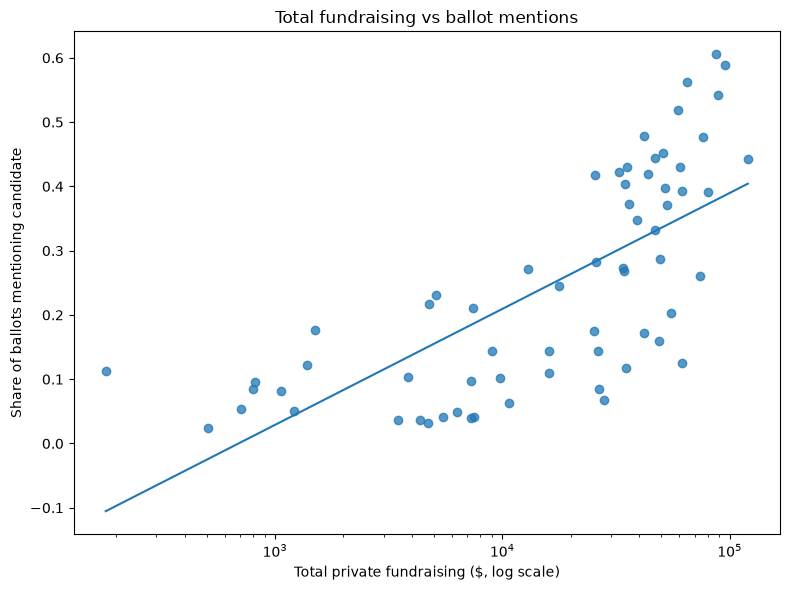

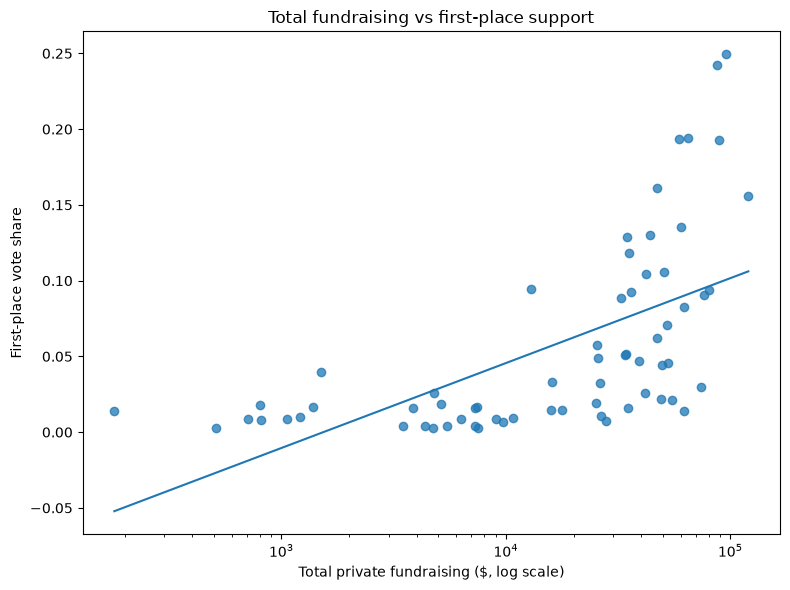

In [9]:
def scatter_with_fit(frame, x, y, title, x_label, y_label):
    plot_data = frame[[x, y]].dropna().copy()
    plot_data = plot_data.loc[plot_data[x].gt(0)]

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        plot_data[x],
        plot_data[y],
        alpha=0.75,
    )

    if len(plot_data) >= 2:
        log_x = np.log(plot_data[x].to_numpy())
        coefficients = np.polyfit(
            log_x,
            plot_data[y].to_numpy(),
            deg=1,
        )

        x_line = np.geomspace(
            plot_data[x].min(),
            plot_data[x].max(),
            100,
        )

        y_line = (
            coefficients[0] * np.log(x_line)
            + coefficients[1]
        )

        ax.plot(x_line, y_line, linewidth=1.5)

    ax.set_xscale("log")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()


scatter_with_fit(
    analysis,
    x="total_amount",
    y="mention_share",
    title="Total fundraising vs ballot mentions",
    x_label="Total private fundraising ($, log scale)",
    y_label="Share of ballots mentioning candidate",
)

scatter_with_fit(
    analysis,
    x="total_amount",
    y="first_place_share",
    title="Total fundraising vs first-place support",
    x_label="Total private fundraising ($, log scale)",
    y_label="First-place vote share",
)